\begin{array}{l}
\text{Write a Matlab code to solve:} \\
\begin{aligned}
-\Delta u + 4u &= f(x) \quad \text{in } \Omega \\
u &= 0 \quad \text{on } \partial\Omega
\end{aligned} \\
\text{with } f(x) = \sin(\pi x) \sin(\pi y) + 2\pi^2 \sin(\pi x) \sin(\pi y). \\
\bullet \text{ Plot the discrete solution for several } h. \\
\bullet \text{ Find } L^2 \text{ and } H^1 \text{ errors and their convergence rates, where the } \\
\phantom{\bullet} \text{exact solution } u(x) = \sin(\pi x) \sin(\pi y).
\end{array}


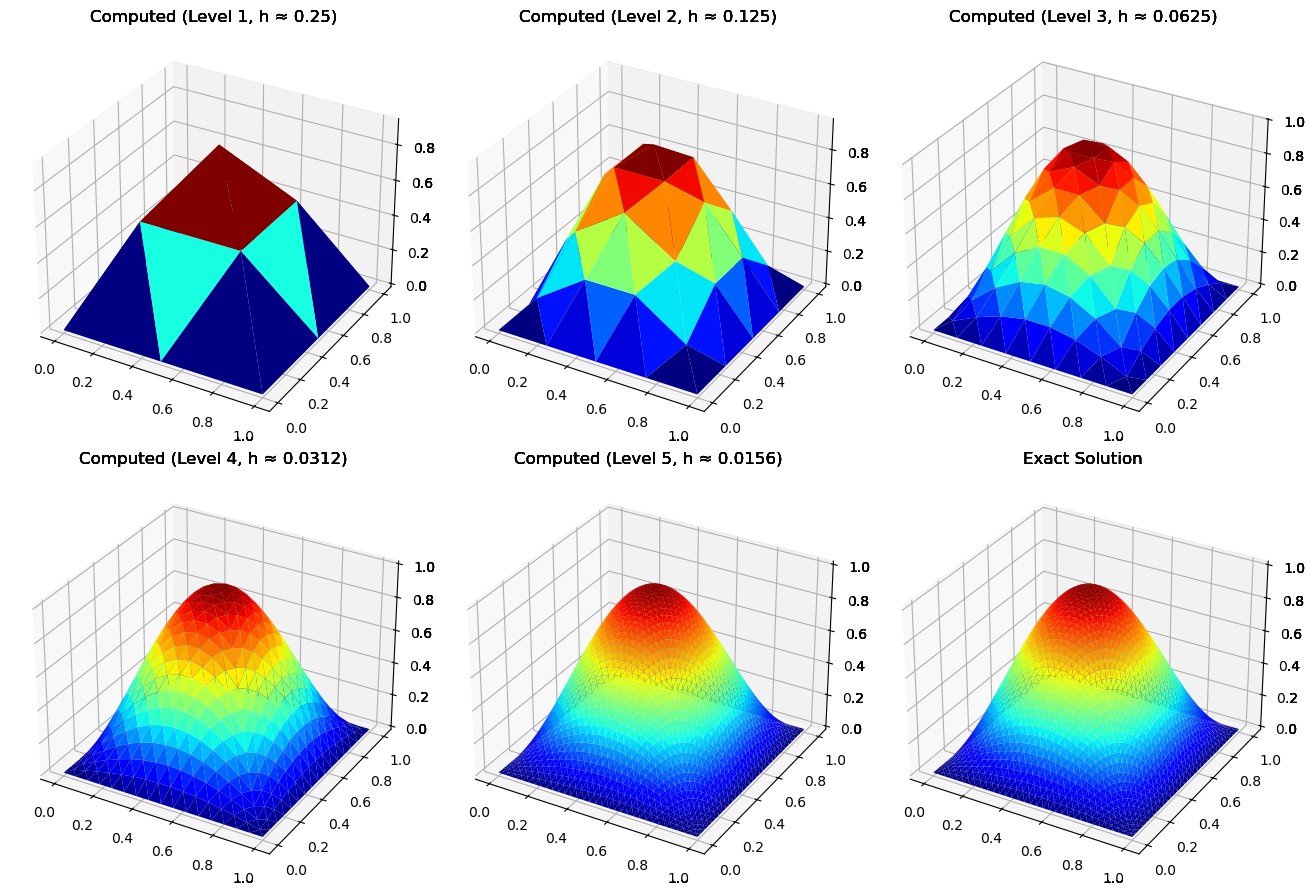


Mesh Size (h) | L2 Error   | H1 Error   | L2 Rate | H1 Rate
-------------------------------------------------------------
0.25          | 0.10141    | 0.481051   |   ---   |   ---  
0.125         | 0.027829   | 0.269527   | 1.8656  | 0.8358 
0.0625        | 0.007262   | 0.141626   | 1.9381  | 0.9283 
0.0312        | 0.001846   | 0.072094   | 1.9763  | 0.9741 
0.0156        | 0.000464   | 0.036257   | 1.9918  | 0.9916 


In [7]:
using LinearAlgebra
using SparseArrays
using PyPlot

# --- Exact Solution and Problem Definitions ---
function ue(z)
    x, y = z[1], z[2]
    return sin(π * x) * sin(π * y)
end

function f(z)
    x, y = z[1], z[2]
    # Mathematically consistent RHS for -\Delta u + 4u
    return (2 * π^2 + 4) * sin(π * x) * sin(π * y)
end

function uxe(z)
    x, y = z[1], z[2]
    return π * cos(π * x) * sin(π * y), π * sin(π * x) * cos(π * y)
end

# --- Mesh Generation and Refinement ---
function InitialMesh()
    # Square Mesh on [0,1] x [0,1]
    Coord = [0.0 0.0; 1.0 0.0; 0.0 1.0; 1.0 1.0; 0.5 0.5]
    Elem = [1 2 5; 1 5 3; 3 5 4; 5 2 4]
    
    # Pure Dirichlet boundary on all 4 sides of the square
    Db = [1 2; 2 4; 4 3; 3 1]
    Nb = zeros(Int, 0, 2) 
    
    return Coord, Elem, Nb, Db
end

function get_edges(element, coordinate)
    n_coord = size(coordinate, 1)
    n_elem = size(element, 1)
    
    nodes2element = spzeros(Int, n_coord, n_coord)
    for j in 1:n_elem
        for k in 1:3
            n1 = element[j, k]
            n2 = element[j, mod1(k+1, 3)]
            nodes2element[n1, n2] += j
        end
    end
    
    B = nodes2element + nodes2element'
    I, J, V = findnz(B)
    
    idx = findall(I .<= J)
    i_idx = I[idx]
    j_idx = J[idx]
    
    n_edges = length(i_idx)
    nodes2edge = sparse(i_idx, j_idx, 1:n_edges, n_coord, n_coord)
    nodes2edge = nodes2edge + nodes2edge'
    
    edge2element = zeros(Int, n_edges, 4)
    for m in 1:n_elem
        for k in 1:3
            n1 = element[m, k]
            n2 = element[m, mod1(k+1, 3)]
            p = nodes2edge[n1, n2]
            if edge2element[p, 1] == 0
                edge2element[p, 1] = n1
                edge2element[p, 2] = n2
                edge2element[p, 3] = nodes2element[n1, n2]
                edge2element[p, 4] = nodes2element[n2, n1]
            end
        end
    end
    return nodes2edge, edge2element
end

function redrefine(Coord, Elem, n2ed, ed2el, Db, Nb)
    nt = size(Elem, 1)
    ne = size(ed2el, 1)
    marker = zeros(Int, ne)
    
    new_nodes = size(Coord, 1)
    nCoord_list = Vector{Vector{Float64}}()
    
    for i in 1:ne
        inode = ed2el[i, 1]
        enode = ed2el[i, 2]
        coord1 = Coord[inode, :]
        coord2 = Coord[enode, :]
        nCoord = (coord1 + coord2) / 2.0
        new_nodes += 1
        marker[i] = new_nodes
        push!(nCoord_list, nCoord)
    end
    
    if !isempty(nCoord_list)
        Coord = vcat(Coord, hcat(nCoord_list...)')
    end
    
    new_Elem = zeros(Int, nt * 4, 3)
    for i in 1:nt
        ct = Elem[i, :]
        ce = [n2ed[ct[2], ct[3]], n2ed[ct[3], ct[1]], n2ed[ct[1], ct[2]]]
        m1 = marker[ce[1]]; m2 = marker[ce[2]]; m3 = marker[ce[3]]
        
        idx = (i - 1) * 4
        new_Elem[idx+1, :] = [m1, m2, m3]
        new_Elem[idx+2, :] = [ct[1], m3, m2]
        new_Elem[idx+3, :] = [ct[2], m1, m3]
        new_Elem[idx+4, :] = [ct[3], m2, m1]
    end
    Elem = new_Elem
    
    if !isempty(Db)
        nb = size(Db, 1)
        new_Db = zeros(Int, nb * 2, 2)
        count = 1
        for i in 1:nb
            base = n2ed[Db[i, 1], Db[i, 2]]
            if marker[base] > 0
                m = marker[base]
                new_Db[count, :] = [Db[i, 1], m]
                new_Db[count+1, :] = [m, Db[i, 2]]
                count += 2
            end
        end
        Db = new_Db[1:count-1, :]
    end
    return Coord, Elem, Db, Nb
end

# --- Core FEM Solvers and Error Tracking ---
function stima(vertices)
    MatT = vcat(ones(1, 3), vertices')'
    mk = 0.5 * abs(det(MatT'))
    
    L1 = MatT \ [1.0, 0.0, 0.0]
    L2 = MatT \ [0.0, 1.0, 0.0]
    L3 = MatT \ [0.0, 0.0, 1.0]
    
    M = mk * [
        L1[2]^2+L1[3]^2          L1[2]*L2[2]+L1[3]*L2[3]  L1[2]*L3[2]+L1[3]*L3[3];
        L2[2]*L1[2]+L2[3]*L1[3]  L2[2]^2+L2[3]^2          L2[2]*L3[2]+L2[3]*L3[3];
        L3[2]*L1[2]+L3[3]*L1[3]  L3[2]*L2[2]+L3[3]*L2[3]  L3[2]^2+L3[3]^2
    ]
       
    # Mass Matrix for +4u
    N_mat = 4.0 * mk * [1/6 1/12 1/12; 1/12 1/6 1/12; 1/12 1/12 1/6]
    
    return M + N_mat
end

function Err(Coord, Elem, uh, u)
    L2e = 0.0; H1e = 0.0
    
    for j in 1:size(Elem, 1)
        curnodes = Elem[j, :]
        curcoords = Coord[curnodes, :]
        Cuh = uh[curnodes]; Cu = u[curnodes]
        
        P1 = curcoords[1, :]; P2 = curcoords[2, :]; P3 = curcoords[3, :]
        mp12 = 0.5 * (P1 + P2); mp13 = 0.5 * (P1 + P3); mp23 = 0.5 * (P3 + P2)
        cg = (P1 + P2 + P3) / 3.0
        
        uhmp12 = 0.5 * (Cuh[1] + Cuh[2]); uhmp13 = 0.5 * (Cuh[1] + Cuh[3]); uhmp23 = 0.5 * (Cuh[3] + Cuh[2])
        uhcg = sum(Cuh) / 3.0
        
        MatT = vcat(ones(1, 3), curcoords')'
        mk = 0.5 * abs(det(MatT'))
        
        L2e += mk / 60.0 * (
            8 * (ue(mp12) - uhmp12)^2 + 8 * (ue(mp13) - uhmp13)^2 + 8 * (ue(mp23) - uhmp23)^2 +
            3 * (Cu[1] - Cuh[1])^2 + 3 * (Cu[2] - Cuh[2])^2 + 3 * (Cu[3] - Cuh[3])^2 + 
            27 * (ue(cg) - uhcg)^2
        )
        
        L1 = MatT \ [1.0, 0.0, 0.0]; L2 = MatT \ [0.0, 1.0, 0.0]; L3 = MatT \ [0.0, 0.0, 1.0]
        uxh = Cuh[1]*L1[2] + Cuh[2]*L2[2] + Cuh[3]*L3[2]
        uyh = Cuh[1]*L1[3] + Cuh[2]*L2[3] + Cuh[3]*L3[3]
       
        uxev, uyev = uxe(cg)
        H1e += mk * ((uxev - uxh)^2 + (uyev - uyh)^2)
    end
    
    return sqrt(L2e), sqrt(H1e)
end

# --- Main Driver Function ---
function main()
    Coord, Elem, Nb, Db = InitialMesh()
    
    n_levels = 5  # Number of refinements
    h = zeros(n_levels)
    L2e_arr = zeros(n_levels)
    H1e_arr = zeros(n_levels)
    
    # Set up figure for plotting
    fig = figure("Discrete Solutions vs Exact", figsize=(15, 9))
    
    for nl in 1:n_levels
        # Refine Mesh
        n2ed, ed2el = get_edges(Elem, Coord)
        Coord, Elem, Db, Nb = redrefine(Coord, Elem, n2ed, ed2el, Db, Nb)
        
        # Calculate maximum element size h
        h[nl] = sqrt(abs(det(vcat(ones(1, 3), Coord[Elem[1, :], :]'))) / 2.0)
        
        n_nodes = size(Coord, 1)
        Dbnodes = unique(Db)
        FreeNodes = setdiff(1:n_nodes, Dbnodes)
        
        A = spzeros(n_nodes, n_nodes)
        b = zeros(n_nodes)
        
        # Assembly
        for j in 1:size(Elem, 1)
            nodes = Elem[j, :]
            verts = Coord[nodes, :]
            
            A[nodes, nodes] .+= stima(verts)
            
            mk = 0.5 * abs(det(vcat(ones(1, 3), verts')'))
            cg = vec(sum(verts, dims=1) / 3.0)
            b[nodes] .+= mk * f(cg) / 3.0
        end
        
        # Apply Dirichlet Boundary Conditions (u = 0)
        uh = zeros(n_nodes)
        uh[Dbnodes] .= 0.0
        
        # Solve
        uh[FreeNodes] = A[FreeNodes, FreeNodes] \ b[FreeNodes]
        
        # Exact solution and Errors
        u_exact = [ue(Coord[i, :]) for i in 1:n_nodes]
        l2, h1 = Err(Coord, Elem, uh, u_exact)
        L2e_arr[nl] = l2
        H1e_arr[nl] = h1
        
        # --- Plotting this level's discrete solution ---
        ax = fig.add_subplot(2, 3, nl, projection="3d")
        triangles = Elem .- 1 # 0-based indexing for PyPlot
        ax.plot_trisurf(Coord[:, 1], Coord[:, 2], triangles, uh, cmap="jet", edgecolor="none")
        ax.set_title("Computed (Level $nl, h ≈ $(round(h[nl], digits=4)))")
        
        # At the final level, also plot the exact solution in the 6th subplot space
        if nl == n_levels
            ax_exact = fig.add_subplot(2, 3, 6, projection="3d")
            ax_exact.plot_trisurf(Coord[:, 1], Coord[:, 2], triangles, u_exact, cmap="jet", edgecolor="none")
            ax_exact.set_title("Exact Solution")
        end
    end
    
    # Adjust layout and show the plots
    tight_layout()
    display(fig)
    
    # Print Convergence Rates to Terminal
    println("\nMesh Size (h) | L2 Error   | H1 Error   | L2 Rate | H1 Rate")
    println("-------------------------------------------------------------")
    println(rpad(round(h[1], digits=4), 13), " | ", rpad(round(L2e_arr[1], digits=6), 10), " | ", rpad(round(H1e_arr[1], digits=6), 10), " |   ---   |   ---  ")
    
    for ml in 1:(n_levels-1)
        ocl2 = log(L2e_arr[ml] / L2e_arr[ml+1]) / log(h[ml] / h[ml+1])
        och1 = log(H1e_arr[ml] / H1e_arr[ml+1]) / log(h[ml] / h[ml+1])
        
        h_str = rpad(round(h[ml+1], digits=4), 13)
        l2_str = rpad(round(L2e_arr[ml+1], digits=6), 10)
        h1_str = rpad(round(H1e_arr[ml+1], digits=6), 10)
        l2r_str = rpad(round(ocl2, digits=4), 7)
        h1r_str = rpad(round(och1, digits=4), 7)
        
        println("$h_str | $l2_str | $h1_str | $l2r_str | $h1r_str")
    end
end

main()

Write a Matlab code to solve:
$$-\Delta u + u = f(x, y) \text{ in } \Omega$$
$$u = g \text{ on } \partial\Omega$$
Select $f, g$ such that $u(x, y) = e^{x+y}$ is the exact solution.

$\bullet$ Plot the discrete solution and compare with the exact solution $u(x, y)$.


Results for Mesh Size h = 1/32
------------------------------------
L2 Error: 0.0008744532521554798
H1 Error: 0.07058824597022985


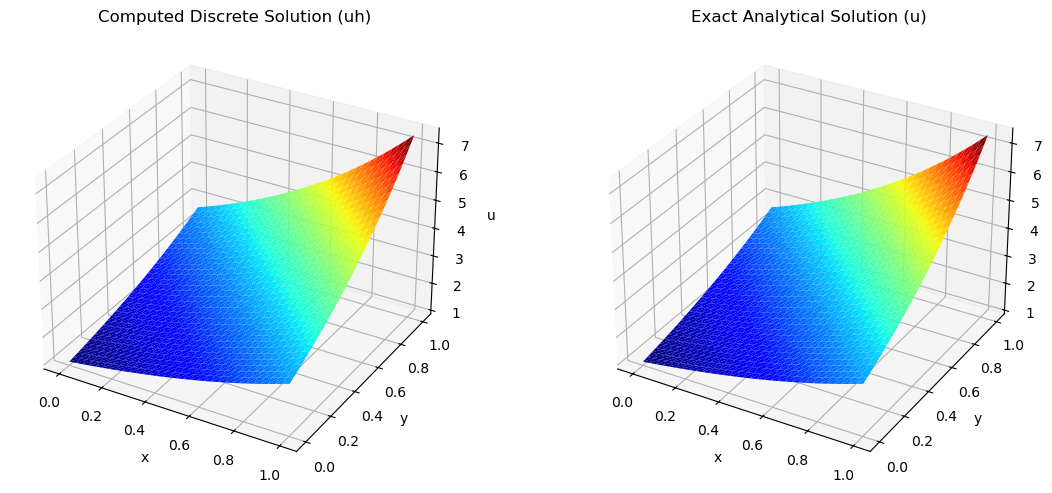

In [8]:
# ==============================================================================
# 2D FEM Solver for:
# - div(grad u) + u = f  in \Omega
#                 u = g  on \partial\Omega
# 
# Exact Solution: u(x, y) = exp(x + y)
# ==============================================================================

using LinearAlgebra
using SparseArrays
using PyPlot

# --- Exact Solution and Problem Definitions ---

function ue(x, y)
    return exp(x + y)
end

function f_src(x, y)
    # If u = e^{x+y}, then \Delta u = 2e^{x+y}.
    # Therefore, - \Delta u + u = -2e^{x+y} + e^{x+y} = -e^{x+y}
    return -exp(x + y)
end

function uxe(x, y)
    # Gradient of exact solution
    return exp(x + y), exp(x + y)
end

# --- Element Stiffness & Mass Matrix ---

function stima(vertices)
    MatT = vcat(ones(1, 3), vertices')'
    mk = 0.5 * abs(det(MatT'))
    
    L1 = MatT \ [1.0, 0.0, 0.0]
    L2 = MatT \ [0.0, 1.0, 0.0]
    L3 = MatT \ [0.0, 0.0, 1.0]
    
    # Stiffness Matrix for -\Delta u
    M = mk * [
        L1[2]^2+L1[3]^2          L1[2]*L2[2]+L1[3]*L2[3]  L1[2]*L3[2]+L1[3]*L3[3];
        L2[2]*L1[2]+L2[3]*L1[3]  L2[2]^2+L2[3]^2          L2[2]*L3[2]+L2[3]*L3[3];
        L3[2]*L1[2]+L3[3]*L1[3]  L3[2]*L2[2]+L3[3]*L2[3]  L3[2]^2+L3[3]^2
    ]
       
    # Mass Matrix for +u
    N_mat = mk * [1/6 1/12 1/12; 1/12 1/6 1/12; 1/12 1/12 1/6]
    
    return M + N_mat
end

# --- Error Computation ---

function compute_errors(Coord, Elem, uh, u_exact)
    L2e = 0.0
    H1e = 0.0
    
    for j in 1:size(Elem, 1)
        nodes = Elem[j, :]
        verts = Coord[nodes, :]
        Cuh = uh[nodes]
        Cu = u_exact[nodes]
        
        P1 = verts[1, :]; P2 = verts[2, :]; P3 = verts[3, :]
        mp12 = 0.5 * (P1 + P2); mp13 = 0.5 * (P1 + P3); mp23 = 0.5 * (P2 + P3)
        cg = (P1 + P2 + P3) / 3.0
        
        uhmp12 = 0.5 * (Cuh[1] + Cuh[2])
        uhmp13 = 0.5 * (Cuh[1] + Cuh[3])
        uhmp23 = 0.5 * (Cuh[2] + Cuh[3])
        uhcg = sum(Cuh) / 3.0
        
        MatT = vcat(ones(1, 3), verts')'
        mk = 0.5 * abs(det(MatT'))
        
        # L2 Error Quadrature
        val_L2 = (mk / 60.0) * (
            8 * (ue(mp12[1], mp12[2]) - uhmp12)^2 +
            8 * (ue(mp13[1], mp13[2]) - uhmp13)^2 +
            8 * (ue(mp23[1], mp23[2]) - uhmp23)^2 +
            3 * (Cu[1] - Cuh[1])^2 + 3 * (Cu[2] - Cuh[2])^2 + 3 * (Cu[3] - Cuh[3])^2 +
            27 * (ue(cg[1], cg[2]) - uhcg)^2
        )
        L2e += val_L2
        
        # H1 Error Quadrature
        L1 = MatT \ [1.0, 0.0, 0.0]; L2 = MatT \ [0.0, 1.0, 0.0]; L3 = MatT \ [0.0, 0.0, 1.0]
        uxh = Cuh[1]*L1[2] + Cuh[2]*L2[2] + Cuh[3]*L3[2]
        uyh = Cuh[1]*L1[3] + Cuh[2]*L2[3] + Cuh[3]*L3[3]
        
        grad_ue = uxe(cg[1], cg[2])
        H1e += mk * ((grad_ue[1] - uxh)^2 + (grad_ue[2] - uyh)^2)
    end
    
    return sqrt(L2e), sqrt(H1e)
end

# --- Main Driver Function ---

function main()
    # 1. Generate a single, sufficiently dense mesh (N=32) for a smooth plot
    N = 32
    h = 1.0 / N
    n_nodes_1d = N + 1
    n_nodes = n_nodes_1d^2
    
    Coord = zeros(n_nodes, 2)
    count = 1
    for j in 1:n_nodes_1d
        for i in 1:n_nodes_1d
            Coord[count, 1] = (i - 1) * h
            Coord[count, 2] = (j - 1) * h
            count += 1
        end
    end
    
    Elem = zeros(Int, 2 * N^2, 3)
    count = 1
    for j in 1:N
        for i in 1:N
            n1 = i + (j - 1) * n_nodes_1d
            n2 = i + 1 + (j - 1) * n_nodes_1d
            n3 = i + j * n_nodes_1d
            n4 = i + 1 + j * n_nodes_1d
            Elem[count, :] = [n1, n2, n4]
            Elem[count+1, :] = [n1, n4, n3]
            count += 2
        end
    end
    
    # 2. Identify Boundary Nodes (Dirichlet \partial\Omega)
    tol = 1e-10
    Db_nodes = Int[]
    for i in 1:n_nodes
        if Coord[i, 1] < tol || Coord[i, 1] > 1-tol || Coord[i, 2] < tol || Coord[i, 2] > 1-tol
            push!(Db_nodes, i)
        end
    end
    FreeNodes = setdiff(1:n_nodes, Db_nodes)
    
    # 3. Initialize Global Matrices
    A = spzeros(n_nodes, n_nodes)
    b = zeros(n_nodes)
    
    # 4. Assemble Stiffness Matrix (A) and Load Vector (b)
    for j in 1:size(Elem, 1)
        nodes = Elem[j, :]
        verts = Coord[nodes, :]
        
        A[nodes, nodes] .+= stima(verts)
        
        mk = 0.5 * abs(det(vcat(ones(1, 3), verts')'))
        cg = vec(sum(verts, dims=1) / 3.0)
        b[nodes] .+= (mk / 3.0) * f_src(cg[1], cg[2])
    end
    
    # 5. Apply Non-Zero Dirichlet Boundary Conditions (u = g)
    uh = zeros(n_nodes)
    for node in Db_nodes
        uh[node] = ue(Coord[node, 1], Coord[node, 2])
    end
    
    # VERY IMPORTANT: Adjust RHS for non-zero boundaries
    b .-= A * uh
    
    # 6. Solve the linear system
    uh[FreeNodes] = A[FreeNodes, FreeNodes] \ b[FreeNodes]
    
    # 7. Exact solution and Error Calculation
    u_exact = [ue(Coord[i, 1], Coord[i, 2]) for i in 1:n_nodes]
    L2e, H1e = compute_errors(Coord, Elem, uh, u_exact)
    
    println("Results for Mesh Size h = 1/$N")
    println("------------------------------------")
    println("L2 Error: ", L2e)
    println("H1 Error: ", H1e)
    
    # 8. Plotting Discrete vs Exact Solution
    fig = figure("FEM Solution", figsize=(12, 5))
    triangles = Elem .- 1 # Convert to 0-based indexing for PyPlot
    
    # Subplot 1: Computed Solution
    ax1 = fig.add_subplot(1, 2, 1, projection="3d")
    ax1.plot_trisurf(Coord[:, 1], Coord[:, 2], triangles, uh, cmap="jet", edgecolor="none")
    ax1.set_title("Computed Discrete Solution (uh)")
    ax1.set_xlabel("x")
    ax1.set_ylabel("y")
    ax1.set_zlabel("u")
    
    # Subplot 2: Exact Solution
    ax2 = fig.add_subplot(1, 2, 2, projection="3d")
    ax2.plot_trisurf(Coord[:, 1], Coord[:, 2], triangles, u_exact, cmap="jet", edgecolor="none")
    ax2.set_title("Exact Analytical Solution (u)")
    ax2.set_xlabel("x")
    ax2.set_ylabel("y")
    ax2.set_zlabel("u")
    
    tight_layout()
    display(fig) # Use display(fig) for VS Code notebooks
end

# Run the simulation
main()

Write a Matlab code to solve:

$$-\Delta u + xu = f(x, y) \text{ in } \Omega$$
$$\frac{\partial u}{\partial n} = g \text{ on } \partial\Omega$$

Select $f, g$ functions such that $u(x, y) = e^{x+y}$ is the exact solution.

$\bullet$ Plot the discrete solution and compare with the exact solution.


Results for Mesh Size h = 1/32 (Pure Neumann)
-------------------------------------------------
L2 Error: 0.0009759919320015948
H1 Error: 0.07033207483650382


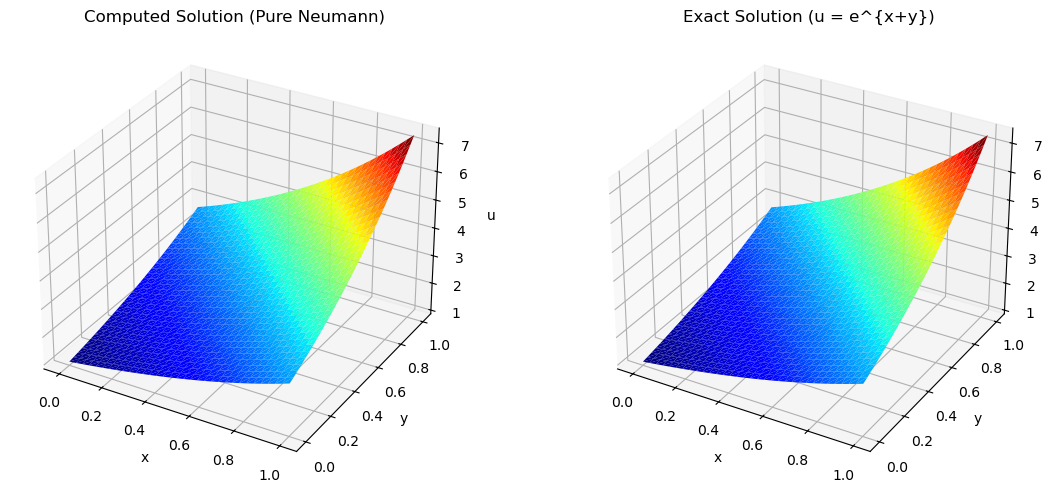

In [9]:
# ==============================================================================
# 2D FEM Solver for:
# - div(grad u) + x*u = f  in \Omega
#             grad u . n = g  on \partial\Omega  (Pure Neumann)
# 
# Exact Solution: u(x, y) = exp(x + y)
# ==============================================================================

using LinearAlgebra
using SparseArrays
using PyPlot

# --- Exact Solution and Problem Definitions ---

function ue(x, y)
    return exp(x + y)
end

function f_src(x, y)
    # If u = e^{x+y}, then \Delta u = 2e^{x+y}.
    # Therefore, - \Delta u + xu = -2e^{x+y} + x e^{x+y} = (x - 2)e^{x+y}
    return (x - 2.0) * exp(x + y)
end

function uxe(x, y)
    # Gradient of exact solution: (du/dx, du/dy)
    return exp(x + y), exp(x + y)
end

function g_val(P1, P2)
    # Computes the exact Neumann boundary value g = grad u . n
    dx = P2[1] - P1[1]
    dy = P2[2] - P1[2]
    len = sqrt(dx^2 + dy^2)
    
    # Outward unit normal vector for counter-clockwise boundary traversal
    nx = dy / len
    ny = -dx / len
    
    # Evaluate gradient at the midpoint of the boundary edge
    x_m = 0.5 * (P1[1] + P2[1])
    y_m = 0.5 * (P1[2] + P2[2])
    grad_x, grad_y = uxe(x_m, y_m)
    
    return grad_x * nx + grad_y * ny
end

# --- Element Stiffness & Mass Matrix ---

function stima(vertices)
    MatT = vcat(ones(1, 3), vertices')'
    mk = 0.5 * abs(det(MatT'))
    
    L1 = MatT \ [1.0, 0.0, 0.0]
    L2 = MatT \ [0.0, 1.0, 0.0]
    L3 = MatT \ [0.0, 0.0, 1.0]
    
    # Stiffness Matrix for -\Delta u
    M = mk * [
        L1[2]^2+L1[3]^2          L1[2]*L2[2]+L1[3]*L2[3]  L1[2]*L3[2]+L1[3]*L3[3];
        L2[2]*L1[2]+L2[3]*L1[3]  L2[2]^2+L2[3]^2          L2[2]*L3[2]+L2[3]*L3[3];
        L3[2]*L1[2]+L3[3]*L1[3]  L3[2]*L2[2]+L3[3]*L2[3]  L3[2]^2+L3[3]^2
    ]
       
    # Mass Matrix for + x*u
    # We evaluate 'x' at the centroid of the triangle to scale the mass matrix
    cg_x = (vertices[1, 1] + vertices[2, 1] + vertices[3, 1]) / 3.0
    N_mat = cg_x * mk * [1/6 1/12 1/12; 1/12 1/6 1/12; 1/12 1/12 1/6]
    
    return M + N_mat
end

# --- Error Computation ---

function compute_errors(Coord, Elem, uh, u_exact)
    L2e = 0.0
    H1e = 0.0
    
    for j in 1:size(Elem, 1)
        nodes = Elem[j, :]
        verts = Coord[nodes, :]
        Cuh = uh[nodes]
        Cu = u_exact[nodes]
        
        P1 = verts[1, :]; P2 = verts[2, :]; P3 = verts[3, :]
        mp12 = 0.5 * (P1 + P2); mp13 = 0.5 * (P1 + P3); mp23 = 0.5 * (P2 + P3)
        cg = (P1 + P2 + P3) / 3.0
        
        uhmp12 = 0.5 * (Cuh[1] + Cuh[2]); uhmp13 = 0.5 * (Cuh[1] + Cuh[3]); uhmp23 = 0.5 * (Cuh[2] + Cuh[3])
        uhcg = sum(Cuh) / 3.0
        
        MatT = vcat(ones(1, 3), verts')'
        mk = 0.5 * abs(det(MatT'))
        
        # L2 Error Quadrature
        val_L2 = (mk / 60.0) * (
            8 * (ue(mp12[1], mp12[2]) - uhmp12)^2 +
            8 * (ue(mp13[1], mp13[2]) - uhmp13)^2 +
            8 * (ue(mp23[1], mp23[2]) - uhmp23)^2 +
            3 * (Cu[1] - Cuh[1])^2 + 3 * (Cu[2] - Cuh[2])^2 + 3 * (Cu[3] - Cuh[3])^2 +
            27 * (ue(cg[1], cg[2]) - uhcg)^2
        )
        L2e += val_L2
        
        # H1 Error Quadrature
        L1 = MatT \ [1.0, 0.0, 0.0]; L2 = MatT \ [0.0, 1.0, 0.0]; L3 = MatT \ [0.0, 0.0, 1.0]
        uxh = Cuh[1]*L1[2] + Cuh[2]*L2[2] + Cuh[3]*L3[2]
        uyh = Cuh[1]*L1[3] + Cuh[2]*L2[3] + Cuh[3]*L3[3]
        
        grad_ue = uxe(cg[1], cg[2])
        H1e += mk * ((grad_ue[1] - uxh)^2 + (grad_ue[2] - uyh)^2)
    end
    
    return sqrt(L2e), sqrt(H1e)
end

# --- Main Driver Function ---

function main()
    # 1. Generate a structured 32x32 mesh
    N = 32
    h = 1.0 / N
    n_nodes_1d = N + 1
    n_nodes = n_nodes_1d^2
    
    Coord = zeros(n_nodes, 2)
    for j in 1:n_nodes_1d
        for i in 1:n_nodes_1d
            idx = i + (j - 1) * n_nodes_1d
            Coord[idx, 1] = (i - 1) * h
            Coord[idx, 2] = (j - 1) * h
        end
    end
    
    Elem = zeros(Int, 2 * N^2, 3)
    count = 1
    for j in 1:N
        for i in 1:N
            n1 = i + (j - 1) * n_nodes_1d
            n2 = i + 1 + (j - 1) * n_nodes_1d
            n3 = i + j * n_nodes_1d
            n4 = i + 1 + j * n_nodes_1d
            Elem[count, :] = [n1, n2, n4]
            Elem[count+1, :] = [n1, n4, n3]
            count += 2
        end
    end
    
    # 2. Extract Boundary Edges for Neumann conditions (ordered counter-clockwise)
    Nb = zeros(Int, 4 * N, 2)
    idx = 1
    for i in 1:N
        Nb[idx, :] = [i, i + 1]; idx += 1                                              # Bottom
        Nb[idx, :] = [N + 1 + (i - 1) * n_nodes_1d, N + 1 + i * n_nodes_1d]; idx += 1  # Right
        Nb[idx, :] = [i + 1 + N * n_nodes_1d, i + N * n_nodes_1d]; idx += 1            # Top
        Nb[idx, :] = [1 + i * n_nodes_1d, 1 + (i - 1) * n_nodes_1d]; idx += 1          # Left
    end
    
    # 3. Initialize Global Matrices
    A = spzeros(n_nodes, n_nodes)
    b = zeros(n_nodes)
    
    # 4. Assemble Stiffness Matrix (A) and Body Load Vector (b)
    for j in 1:size(Elem, 1)
        nodes = Elem[j, :]
        verts = Coord[nodes, :]
        
        A[nodes, nodes] .+= stima(verts)
        
        mk = 0.5 * abs(det(vcat(ones(1, 3), verts')'))
        cg = vec(sum(verts, dims=1) / 3.0)
        b[nodes] .+= (mk / 3.0) * f_src(cg[1], cg[2])
    end
    
    # 5. Apply Neumann Boundary Conditions (Add edge integrals to b)
    for j in 1:size(Nb, 1)
        n1 = Nb[j, 1]
        n2 = Nb[j, 2]
        P1 = Coord[n1, :]
        P2 = Coord[n2, :]
        
        len = norm(P2 - P1)
        # Quadrature over the boundary edge
        val = (len / 2.0) * g_val(P1, P2) 
        
        b[n1] += val
        b[n2] += val
    end
    
    # 6. Solve the linear system
    # (Pure Neumann is solvable here because the +x*u term makes 'A' positive definite)
    uh = A \ b
    
    # 7. Exact solution and Error Calculation
    u_exact = [ue(Coord[i, 1], Coord[i, 2]) for i in 1:n_nodes]
    L2e, H1e = compute_errors(Coord, Elem, uh, u_exact)
    
    println("Results for Mesh Size h = 1/$N (Pure Neumann)")
    println("-------------------------------------------------")
    println("L2 Error: ", L2e)
    println("H1 Error: ", H1e)
    
    # 8. Plotting Discrete vs Exact Solution
    fig = figure("FEM Solution - Neumann Boundary", figsize=(12, 5))
    triangles = Elem .- 1 # Convert to 0-based indexing for PyPlot
    
    # Subplot 1: Computed Solution
    ax1 = fig.add_subplot(1, 2, 1, projection="3d")
    ax1.plot_trisurf(Coord[:, 1], Coord[:, 2], triangles, uh, cmap="jet", edgecolor="none")
    ax1.set_title("Computed Solution (Pure Neumann)")
    ax1.set_xlabel("x")
    ax1.set_ylabel("y")
    ax1.set_zlabel("u")
    
    # Subplot 2: Exact Solution
    ax2 = fig.add_subplot(1, 2, 2, projection="3d")
    ax2.plot_trisurf(Coord[:, 1], Coord[:, 2], triangles, u_exact, cmap="jet", edgecolor="none")
    ax2.set_title("Exact Solution (u = e^{x+y})")
    ax2.set_xlabel("x")
    ax2.set_ylabel("y")
    ax2.set_zlabel("u")
    
    tight_layout()
    display(fig) # Show perfectly in VS Code Jupyter notebook
end

# Run the simulation
main()